In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

In [2]:
# Ajusta la ruta al archivo descargado de Kaggle
df = pd.read_csv("meningmissing12.csv")

df.head()


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


In [3]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        1200 non-null   int64  
 1   Age               1193 non-null   float64
 2   Gender            1191 non-null   str    
 3   WBC_Count         1192 non-null   float64
 4   Protein_Level     1190 non-null   float64
 5   Glucose_Level     1192 non-null   float64
 6   Pathogen_Present  1192 non-null   str    
 7   Diagnosis         1188 non-null   str    
 8   Outcome           1190 non-null   str    
 9   Hemoglobin        1181 non-null   float64
 10  WBC_Blood_Count   1190 non-null   float64
 11  Platelets         1188 non-null   float64
 12  CRP_Level         1187 non-null   float64
 13  Risk_Level        1200 non-null   str    
dtypes: float64(8), int64(1), str(5)
memory usage: 131.4 KB


Patient_ID           0
Age                  7
Gender               9
WBC_Count            8
Protein_Level       10
Glucose_Level        8
Pathogen_Present     8
Diagnosis           12
Outcome             10
Hemoglobin          19
WBC_Blood_Count     10
Platelets           12
CRP_Level           13
Risk_Level           0
dtype: int64

In [4]:
X = df.drop("Outcome", axis=1)   # Ajusta el nombre de la columna target si es distinto
y = df["Outcome"]

In [5]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64","float64"]).columns

print("Categóricas:", categorical_cols)
print("Numéricas:", numeric_cols)

Categóricas: Index(['Gender', 'Pathogen_Present', 'Diagnosis', 'Risk_Level'], dtype='str')
Numéricas: Index(['Patient_ID', 'Age', 'WBC_Count', 'Protein_Level', 'Glucose_Level',
       'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level'],
      dtype='str')


C:\Users\aaran\AppData\Local\Temp\ipykernel_27884\3610910665.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


In [6]:
# Imputación + codificación para categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Imputación + escalado para numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combinar en un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_cols),
        ("numeric", numeric_transformer, numeric_cols)
    ]
)


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

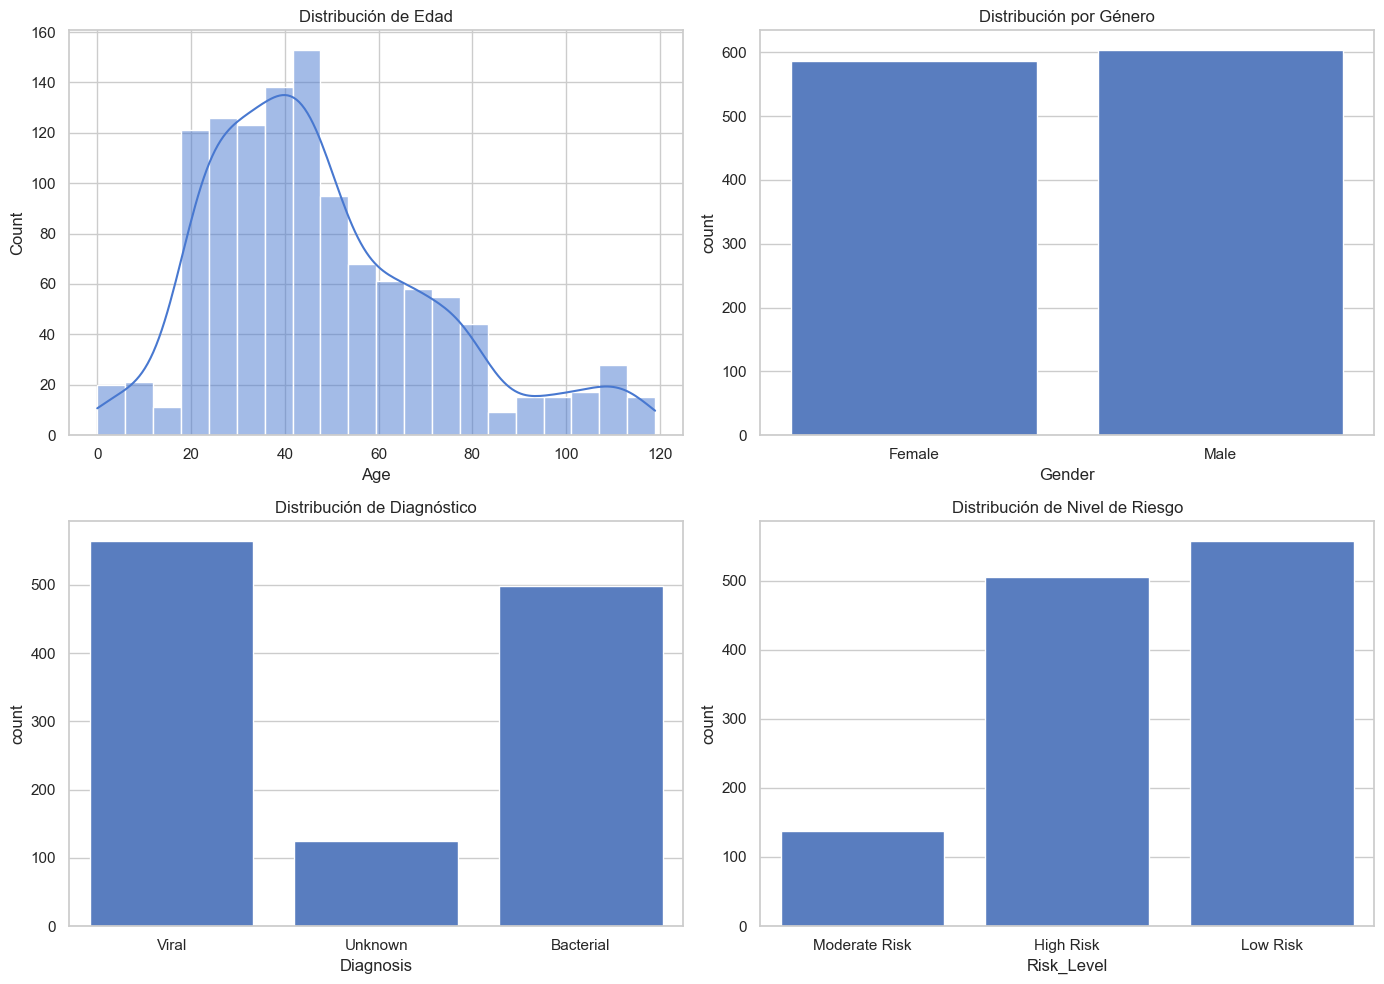

In [10]:
# Configuración estética
sns.set(style="whitegrid", palette="muted")

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Distribución de edades
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title("Distribución de Edad")

# Conteo por género
sns.countplot(x="Gender", data=df, ax=axes[0,1])
axes[0,1].set_title("Distribución por Género")

# Conteo de diagnóstico
sns.countplot(x="Diagnosis", data=df, ax=axes[1,0])
axes[1,0].set_title("Distribución de Diagnóstico")

# Conteo de nivel de riesgo
sns.countplot(x="Risk_Level", data=df, ax=axes[1,1])
axes[1,1].set_title("Distribución de Nivel de Riesgo")

plt.tight_layout()
plt.show()


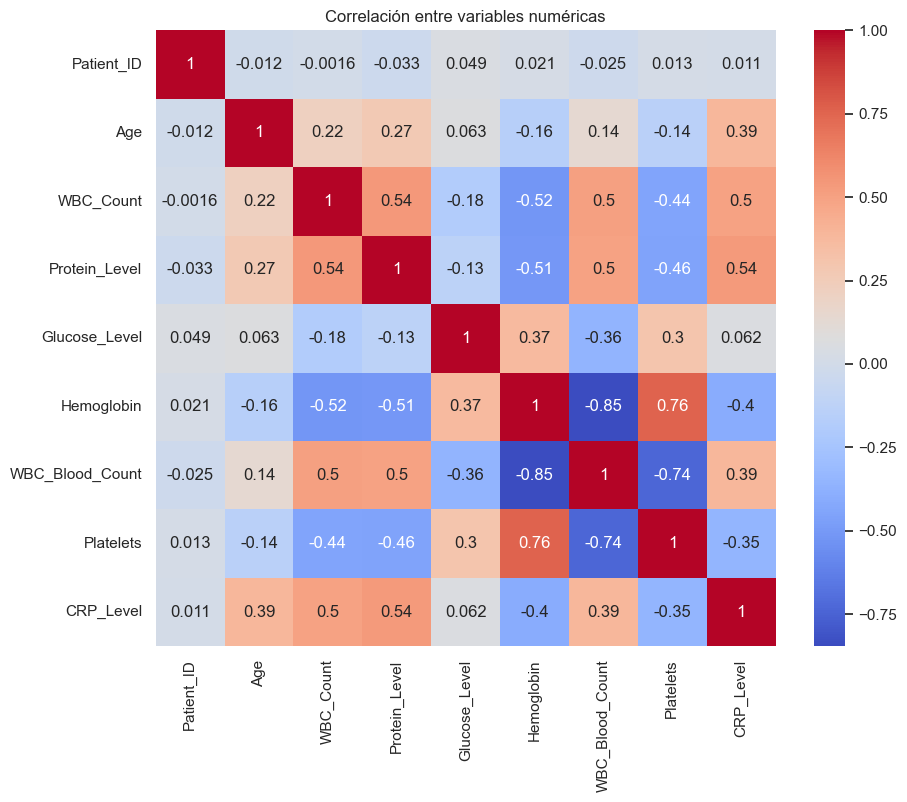

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre variables numéricas")
plt.show()
